### The data set has information about features of silhouette extracted from the images of different cars

Four "Corgie" model vehicles were used for the experiment: a double decker bus, Cheverolet van, Saab 9000 and an Opel Manta 400 cars. This particular combination of vehicles was chosen with the expectation that the bus, van and either one of the cars would be readily distinguishable, but it would be more difficult to distinguish between the cars.



### 1. Read the dataset using function .dropna() - to avoid dealing with NAs as of now

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

df = pd.read_csv("vehicle.csv")
df=df.dropna()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 813 entries, 0 to 845
Data columns (total 19 columns):
compactness                    813 non-null int64
circularity                    813 non-null float64
distance_circularity           813 non-null float64
radius_ratio                   813 non-null float64
pr.axis_aspect_ratio           813 non-null float64
max.length_aspect_ratio        813 non-null int64
scatter_ratio                  813 non-null float64
elongatedness                  813 non-null float64
pr.axis_rectangularity         813 non-null float64
max.length_rectangularity      813 non-null int64
scaled_variance                813 non-null float64
scaled_variance.1              813 non-null float64
scaled_radius_of_gyration      813 non-null float64
scaled_radius_of_gyration.1    813 non-null float64
skewness_about                 813 non-null float64
skewness_about.1               813 non-null float64
skewness_about.2               813 non-null float64
hollows_ratio    

### 2. Print/ Plot the dependent (categorical variable) - Class column

Since the variable is categorical, you can use value_counts function

In [12]:
df['class'].value_counts()

car    413
bus    205
van    195
Name: class, dtype: int64

### Check for any missing values in the data 

In [13]:
df.isna().sum()

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

### 3. Standardize the data 

In [14]:
from scipy.stats import zscore

numeric_cols = df.drop('class', axis=1)

class_names = pd.DataFrame(df[['class']])

In [21]:
df_z = numeric_cols.apply(zscore)
df = numeric_cols.join(class_names)   # Recreating df by combining numerical columns with class names

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 813 entries, 0 to 845
Data columns (total 19 columns):
compactness                    813 non-null int64
circularity                    813 non-null float64
distance_circularity           813 non-null float64
radius_ratio                   813 non-null float64
pr.axis_aspect_ratio           813 non-null float64
max.length_aspect_ratio        813 non-null int64
scatter_ratio                  813 non-null float64
elongatedness                  813 non-null float64
pr.axis_rectangularity         813 non-null float64
max.length_rectangularity      813 non-null int64
scaled_variance                813 non-null float64
scaled_variance.1              813 non-null float64
scaled_radius_of_gyration      813 non-null float64
scaled_radius_of_gyration.1    813 non-null float64
skewness_about                 813 non-null float64
skewness_about.1               813 non-null float64
skewness_about.2               813 non-null float64
hollows_ratio    

Since the dimensions of the data are not really known to us, it would be wise to standardize the data using z scores before we go for any clustering methods.
You can use zscore function to do this

### K - Means Clustering

### 4. Assign a dummy array called distortion

You can later use this array to plot the elbow plot

In [23]:
from sklearn.cluster import KMeans

In [27]:
distortion = []

### 5. Calculating distortion - C distance

In [28]:
cluster_range = range( 2, 10)

for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 10)
  clusters.fit(df_z)
  labels = clusters.labels_
  centroids = clusters.cluster_centers_
  distortion.append( clusters.inertia_ )
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": distortion } )
clusters_df[0:15]

,num_clusters,cluster_errors
0,2,8623.136976
1,3,7037.467395
2,4,5741.223045
3,5,5185.886887
4,6,4705.949959
5,7,4349.367587
6,8,4084.474482
7,9,3847.522642


Iterating values of k from 1 to 10 fit K means model
Using c distance - Get the measure for Sum of squares error.

### 6. Plotting Elbow/ Scree Plot

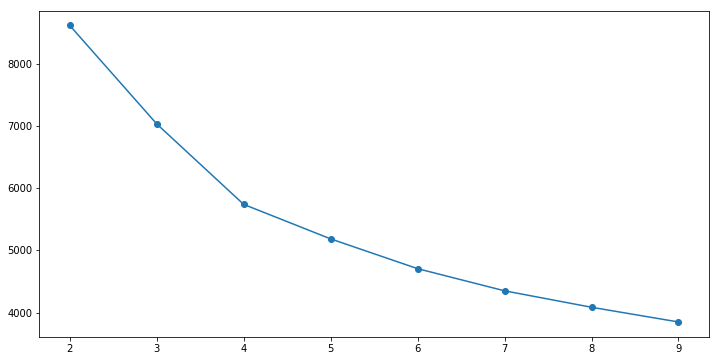

In [30]:
# Elbow plot

%matplotlib inline 
import matplotlib.pyplot as plt 

plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

Use Matplotlib to plot the scree plot - Note: Scree plot plots distortion vs the no of clusters

### Find out the optimal value of K

The elbow plot confirms our visual analysis that there are 3 good clusters.
Let us model with 3 clusters.

### Using optimal value of K - Cluster the data. 
Note: Since the data has more than 2 dimension we cannot visualize the data. As an alternative, we can observe the centroids and note how they are distributed across different dimensions

In [31]:
cluster = KMeans( n_clusters = 3, random_state = 7 )
cluster.fit(df_z)
df_z_copy = df_z.copy(deep = True)  # Creating a mirror copy for later re-use instead of building repeatedly

You can use kmeans.cluster_centers_ function to pull the centroid information from the instance

In [32]:
centroids = cluster.cluster_centers_
centroids

array([[-0.91987072, -0.52009251, -0.89320752, -1.06435572, -0.50042171,
        -0.2190738 , -0.7791213 ,  0.86589322, -0.74535635, -0.484632  ,
        -0.78240328, -0.78341064, -0.38498232,  0.83878747, -0.09524349,
        -0.30171562, -1.05420601, -1.11069466],
       [ 1.13076532,  1.17094237,  1.19500584,  1.01909505,  0.21505188,
         0.34250798,  1.27180461, -1.19061224,  1.27548416,  1.09266768,
         1.22038121,  1.28132727,  1.07954232, -0.02879497,  0.16229031,
         0.26566456, -0.00535553,  0.18380067],
       [-0.2339617 , -0.57387481, -0.30776905, -0.03041322,  0.2050726 ,
        -0.11653151, -0.45904181,  0.32506329, -0.48798836, -0.53604446,
        -0.41380935, -0.46366305, -0.60155031, -0.61924057, -0.06177969,
         0.01066762,  0.81278556,  0.69897299]])

### 7. Store the centroids in a dataframe with column names from the original dataset given 

In [33]:
centroid_df = pd.DataFrame(centroids, columns = list(df_z) )
centroid_df

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,-0.919871,-0.520093,-0.893208,-1.064356,-0.500422,-0.219074,-0.779121,0.865893,-0.745356,-0.484632,-0.782403,-0.783411,-0.384982,0.838787,-0.095243,-0.301716,-1.054206,-1.110695
1,1.130765,1.170942,1.195006,1.019095,0.215052,0.342508,1.271805,-1.190612,1.275484,1.092668,1.220381,1.281327,1.079542,-0.028795,0.162290,0.265665,-0.005356,0.183801
2,-0.233962,-0.573875,-0.307769,-0.030413,0.205073,-0.116532,-0.459042,0.325063,-0.487988,-0.536044,-0.413809,-0.463663,-0.601550,-0.619241,-0.061780,0.010668,0.812786,0.698973


Hint: Use pd.Dataframe function 

### Use kmeans.labels_ function to print out the labels of the classes

In [35]:
cluster.labels_ 

array([2, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 2, 1, 0, 0, 2, 2, 1,
       2, 0, 1, 1, 0, 2, 2, 2, 1, 2, 0, 1, 1, 0, 1, 0, 0, 2, 1, 0, 0, 0,
       0, 2, 0, 2, 1, 2, 1, 2, 2, 0, 1, 0, 1, 0, 0, 0, 2, 0, 1, 2, 1, 1,
       2, 0, 2, 1, 2, 0, 0, 1, 2, 0, 2, 1, 2, 0, 2, 0, 1, 2, 1, 2, 0, 1,
       0, 0, 1, 0, 0, 2, 2, 0, 1, 1, 0, 0, 1, 2, 2, 0, 0, 0, 2, 1, 1, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 2, 1, 1, 2, 2, 0, 1, 1, 0, 2, 0, 2, 2, 1,
       0, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 0, 2, 0, 1, 2, 2, 1, 1,
       2, 1, 0, 0, 1, 1, 2, 1, 2, 2, 2, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1,
       2, 1, 2, 1, 2, 0, 1, 0, 0, 0, 2, 2, 1, 1, 2, 2, 2, 0, 1, 2, 2, 2,
       1, 0, 0, 1, 0, 2, 1, 0, 0, 0, 2, 1, 2, 1, 0, 0, 0, 0, 1, 2, 0, 2,
       1, 0, 2, 2, 0, 1, 0, 0, 2, 2, 1, 0, 1, 0, 2, 2, 1, 2, 2, 1, 1, 0,
       2, 2, 2, 1, 0, 2, 2, 0, 0, 2, 2, 1, 2, 0, 0, 1, 2, 2, 0, 0, 1, 0,
       2, 1, 0, 2, 1, 2, 2, 1, 2, 1, 0, 2, 2, 1, 2, 2, 2, 0, 2, 1, 1, 1,
       1, 0, 2, 1, 0, 0, 0, 2, 0, 1, 1, 0, 1, 2, 0,

In [36]:
df['labels'] = cluster.labels_

df.groupby(["labels"]).count()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
labels,,,,,,,,,,,,,,,,,,,
0,240,240,240,240,240,240,240,240,240,240,240,240,240,240,240,240,240,240,240
1,260,260,260,260,260,260,260,260,260,260,260,260,260,260,260,260,260,260,260
2,313,313,313,313,313,313,313,313,313,313,313,313,313,313,313,313,313,313,313


## Hierarchical Clustering 

### 8. Variable creation

For Hierarchical clustering, we will create datasets using multivariate normal distribution to visually observe how the clusters are formed at the end

In [81]:
a = np.random.multivariate_normal([10, 0], [[3, 1], [1, 4]], size=[100,])
b = np.random.multivariate_normal([0, 20], [[3, 1], [1, 4]], size=[50,])
c = np.random.multivariate_normal([10, 20], [[3, 1], [1, 4]], size=[100,])

In [77]:
np.mean(b[:,0])

-0.0175810352780687

In [78]:
np.mean(b[:,1])

20.001368484634575

In [79]:
np.cov(b[:,0], b[:,1])

array([[2.69824671, 1.16918255],
       [1.16918255, 4.17323072]])

### 9. Combine all three arrays a,b,c into a dataframe

In [90]:
df1 = pd.DataFrame({'Column1':a[:,0],'Column2':a[:,1]})
df2 = pd.DataFrame({'Column3':b[:,0],'Column4':b[:,1]})
df3 = pd.DataFrame({'Column5':c[:,0],'Column6':c[:,1]})

In [92]:
df = pd.concat([df1, df2, df3], axis=1)

In [107]:
df.shape # 100 samples with 6 dimensions

(100, 6)

### 10. Use scatter matrix to print all the 3 distributions

In [108]:
# importing ploting libraries
import matplotlib.pyplot as plt   

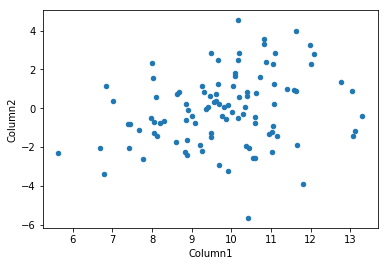

In [110]:
df.plot.scatter(x='Column1', y='Column2')

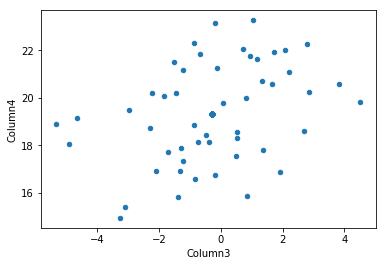

In [111]:
df.plot.scatter(x='Column3', y='Column4')

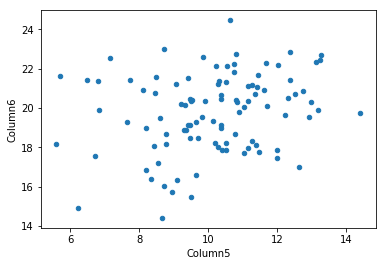

In [112]:
df.plot.scatter(x='Column5', y='Column6')

The three sample distributions show scattered data, no visual clustering

### 11. Find out the linkage matrix

In [113]:
from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist

Use ward as linkage metric and distance as Eucledian

In [114]:
df = df.apply(lambda x: x.fillna(x.median()),axis=0)

In [115]:
Z = linkage(df, method='ward', metric='euclidean')
c, coph_dists = cophenet(Z , pdist(df))

c

0.4671912846770299

In [117]:
Z[0]

array([82.        , 93.        ,  0.24424243,  2.        ])

#In its first iteration the linkage algorithm decided to merge the two clusters (original samples here) with indices 82 and 93, as they only had a distance of 0.24424243. This created a cluster with a total of 2 samples.

In [119]:
Z[:20]

array([[ 82.        ,  93.        ,   0.24424243,   2.        ],
       [ 50.        ,  77.        ,   0.4628968 ,   2.        ],
       [ 59.        ,  99.        ,   1.06693547,   2.        ],
       [ 51.        ,  68.        ,   1.11316595,   2.        ],
       [ 32.        , 102.        ,   1.24384889,   3.        ],
       [ 54.        ,  74.        ,   1.26119777,   2.        ],
       [ 69.        ,  91.        ,   1.32932675,   2.        ],
       [ 73.        ,  80.        ,   1.37447007,   2.        ],
       [ 66.        ,  85.        ,   1.38145144,   2.        ],
       [ 27.        ,  62.        ,   1.40559495,   2.        ],
       [ 92.        , 103.        ,   1.42822818,   3.        ],
       [ 52.        , 101.        ,   1.43642514,   3.        ],
       [ 86.        ,  88.        ,   1.48095335,   2.        ],
       [ 70.        ,  71.        ,   1.56927554,   2.        ],
       [ 38.        ,  58.        ,   1.63266334,   2.        ],
       [ 76.        , 112

### 12. Plot the dendrogram for the consolidated dataframe

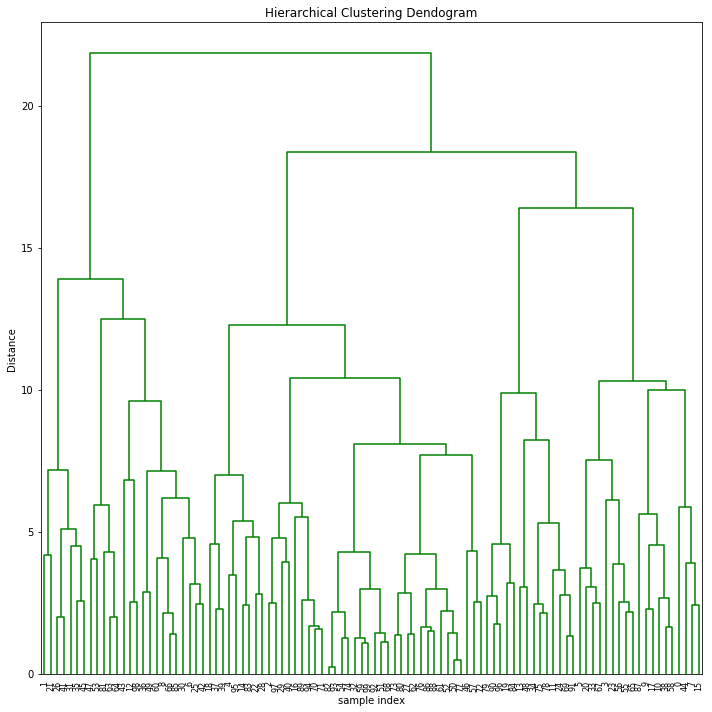

In [104]:
plt.figure(figsize=(10, 10))
plt.title('Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8. )
plt.tight_layout()

### 13. Recreate the dendrogram for last 12 merged clusters 

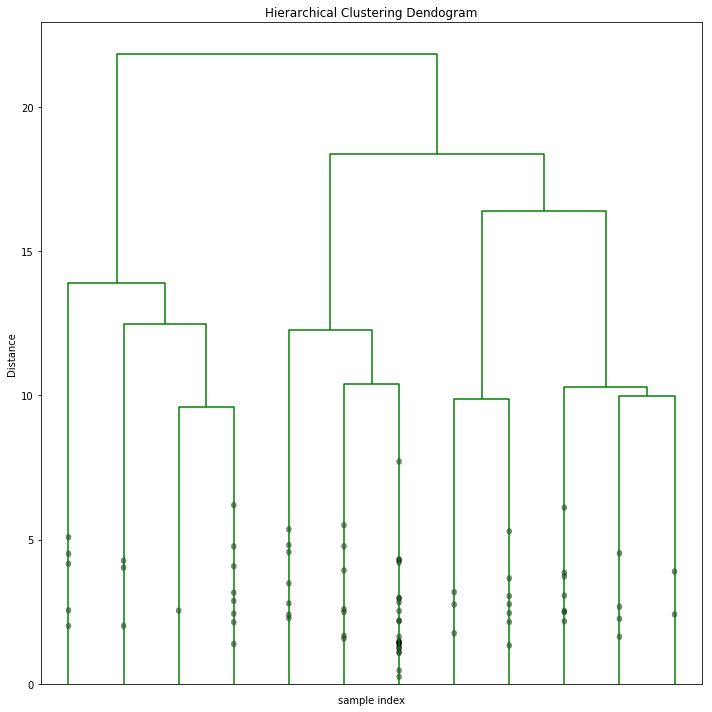

In [120]:
plt.figure(figsize=(10, 10))
plt.title('Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, truncate_mode='lastp',p=12, show_leaf_counts=False, leaf_rotation=90.,leaf_font_size=12., show_contracted=True )
plt.tight_layout()

Hint: Use truncate_mode='lastp' attribute in dendrogram function to arrive at dendrogram 

### 14. From the truncated dendrogram, find out the optimal distance between clusters which u want to use an input for clustering data

In [123]:
from scipy.cluster.hierarchy import inconsistent

depth = 5
incons = inconsistent(Z, depth)
incons[-10:]

array([[ 4.14297108,  2.52341317, 12.        ,  2.27579888],
       [ 4.31609716,  2.60479875,  9.        ,  2.17830927],
       [ 4.79871637,  2.60018746, 16.        ,  2.11815134],
       [ 3.799313  ,  2.50861814, 22.        ,  2.63218027],
       [ 4.97257876,  2.6356668 , 23.        ,  2.76755065],
       [ 5.59421609,  2.95280919, 13.        ,  2.33195638],
       [ 5.73612171,  3.41383125, 18.        ,  2.38632035],
       [ 5.71189325,  3.48189226, 22.        ,  3.07210483],
       [ 6.91174371,  3.82295109, 30.        ,  2.99428982],
       [ 8.5480351 ,  4.6243148 , 29.        ,  2.87444307]])

### 15. Using this distance measure and fcluster function to cluster the data into 3 different groups

In [126]:
from scipy.cluster.hierarchy import fcluster

max_d = 50
clusters = fcluster(Z, max_d, criterion='distance')
clusters

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [128]:
k=3
fcluster(Z, k, criterion='maxclust')

array([3, 1, 2, 3, 2, 3, 1, 3, 1, 3, 3, 3, 1, 3, 2, 3, 2, 3, 2, 3, 3, 1,
       2, 3, 3, 1, 1, 2, 2, 2, 1, 1, 2, 3, 3, 1, 1, 2, 3, 2, 2, 1, 1, 1,
       3, 1, 2, 1, 3, 1, 2, 2, 2, 1, 2, 3, 3, 2, 3, 2, 1, 2, 2, 1, 1, 3,
       1, 3, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2, 3, 3, 2, 1, 2, 2, 3, 1, 2, 3,
       2, 2, 3, 3, 2, 2, 2, 2, 3, 2, 1, 2], dtype=int32)

### Use matplotlib to visually observe the clusters in 2D space 

<Figure size 720x576 with 0 Axes>

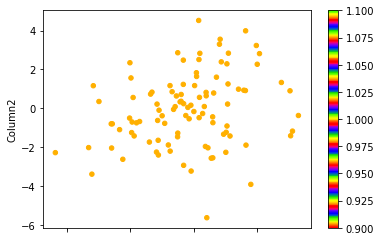

In [131]:
plt.figure(figsize=(10, 8))
df.plot.scatter(x='Column1', y='Column2', c=clusters, cmap='prism')